# 🎓 Datathon — Passos Mágicos
## Análise Exploratória, Modelo Preditivo de Risco e Storytelling
**Curso:** Data Analytics — POSTECH  
**Período:** 2022 · 2023 · 2024  

---
> *"Mudando a vida de crianças e jovens por meio da educação"*  

Este notebook responde às **11 perguntas de negócio** do Datathon e constrói  
um **modelo preditivo de risco de defasagem** usando Machine Learning.


## 0. Setup — Importações e Configuração

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ── Estilo global ─────────────────────────────────────────────────────────────
CORES = {
    'primaria':  '#1B4F72',
    'secundaria':'#2E86C1',
    'destaque':  '#E74C3C',
    'verde':     '#1E8449',
    'amarelo':   '#F39C12',
    'cinza':     '#7F8C8D',
}
PALETA = [CORES['primaria'], CORES['secundaria'], CORES['amarelo'],
          CORES['verde'], CORES['destaque'], CORES['cinza']]

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Carregar base tratada ─────────────────────────────────────────────────────
BASE_PATH = 'BASE_PEDE_TRATADA.xlsx'   # ajuste o caminho se necessário
df = pd.read_excel('/Users/rodrigodevictor/Downloads/Datathon - Analise de Dados/BASE_PEDE_TRATADA.xlsx', sheet_name='BASE_CONSOLIDADA')

print(f"Base carregada: {df.shape[0]:,} registros | {df.shape[1]} colunas")
print(f"Anos: {sorted(df['ano_referencia'].unique())}")
df.head(3)


Base carregada: 3,030 registros | 34 colunas
Anos: [np.int64(2022), np.int64(2023), np.int64(2024)]


,ra,ano_referencia,fase,genero,genero_feminino,idade,data_nascimento,ano_ingresso,anos_no_programa,instituicao,...,nota_portugues,nota_ingles,media_notas,media_indicadores,evolucao_pedra,defasagem,pedra_2022,inde_2022,pedra_2023,inde_2023
0,RA-1,2022,7,Feminino,1,19.0,2003-01-01,2016,6,Pública,...,3.5,6.0,4.066667,6.000000,NaN,-1,NaN,NaN,NaN,NaN
1,RA-2,2022,7,Feminino,1,17.0,2005-01-01,2017,5,Pública,...,4.5,9.7,6.833333,6.766667,NaN,0,NaN,NaN,NaN,NaN
2,RA-3,2022,7,Feminino,1,17.0,2005-01-01,2016,6,Pública,...,4.0,6.9,5.566667,4.500000,NaN,0,NaN,NaN,NaN,NaN


---
## 📌 Pergunta 1 — Adequação do Nível (IAN)
**Qual é o perfil geral de defasagem dos alunos e como ele evolui ao longo dos anos?**

O **IAN (Índice de Adequação de Nível)** assume três valores:  
- `10.0` → Adequado à fase  
- `5.0`  → Moderadamente defasado  
- `2.5`  → Severamente defasado


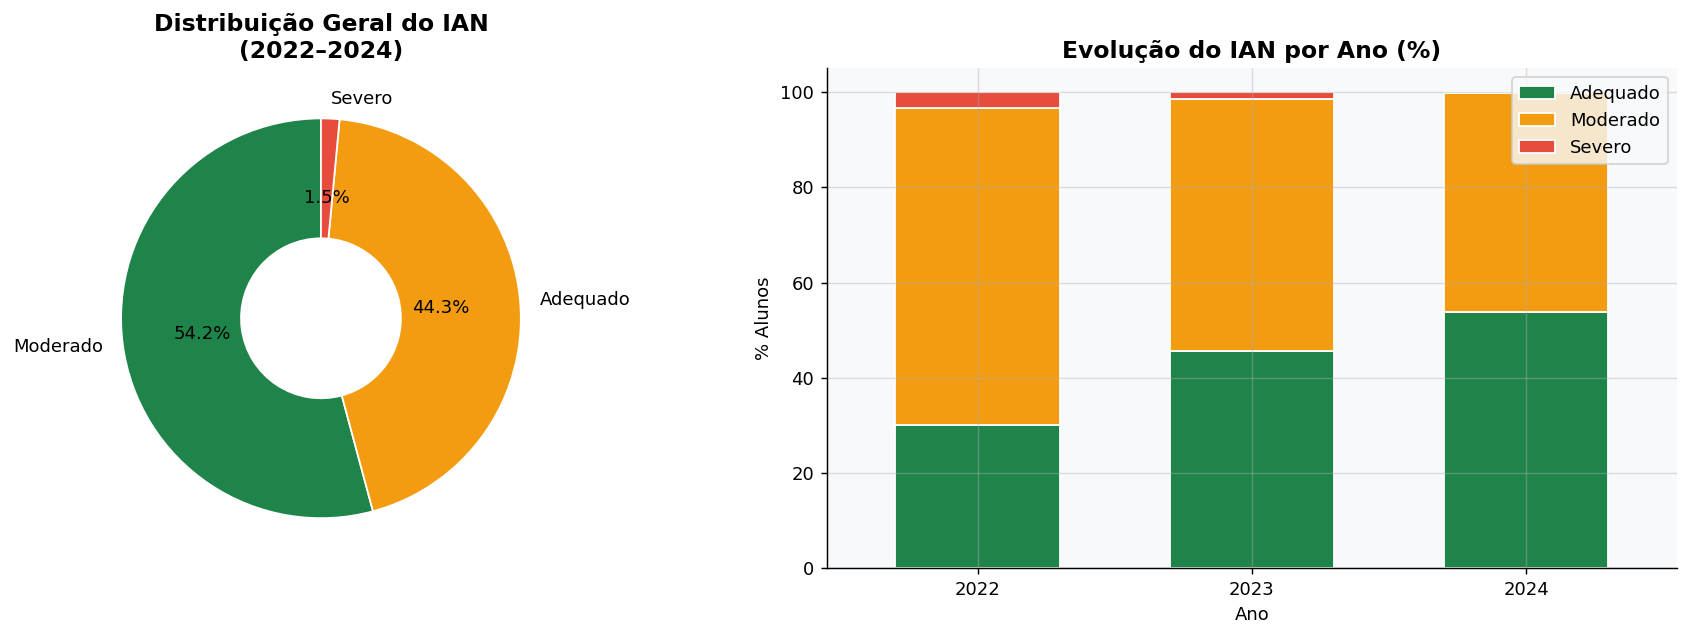


Contagem por ano e nível IAN:
ian_classe      Adequado  Moderado  Severo  Total
ano_referencia                                   
2022                 259       573      28    860
2023                 462       538      14   1014
2024                 622       531       3   1156


In [5]:
# Classificar IAN
def classificar_ian(v):
    if v == 10.0: return 'Adequado'
    if v == 5.0:  return 'Moderado'
    return 'Severo'

df['ian_classe'] = df['ian'].apply(classificar_ian)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Pizza geral
contagem = df['ian_classe'].value_counts()
cores_pizza = [CORES['verde'], CORES['amarelo'], CORES['destaque']]
axes[0].pie(contagem, labels=contagem.index, autopct='%1.1f%%',
            colors=cores_pizza, startangle=90,
            wedgeprops=dict(width=0.6, edgecolor='white'))
axes[0].set_title('Distribuição Geral do IAN\n(2022–2024)', fontsize=13, fontweight='bold')

# -- Evolução anual
evolucao = (df.groupby(['ano_referencia', 'ian_classe'])
              .size().reset_index(name='n'))
pivot = evolucao.pivot(index='ano_referencia', columns='ian_classe', values='n').fillna(0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct[['Adequado','Moderado','Severo']].plot(
    kind='bar', stacked=True, ax=axes[1],
    color=[CORES['verde'], CORES['amarelo'], CORES['destaque']],
    edgecolor='white', width=0.6
)
axes[1].set_title('Evolução do IAN por Ano (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Ano'); axes[1].set_ylabel('% Alunos')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(loc='upper right', framealpha=0.8)

plt.tight_layout()
plt.savefig('fig01_ian.png', bbox_inches='tight')
plt.show()

# Tabela resumo
resumo = df.groupby(['ano_referencia','ian_classe']).size().unstack(fill_value=0)
resumo['Total'] = resumo.sum(axis=1)
print("\nContagem por ano e nível IAN:")
print(resumo)


---
## 📌 Pergunta 2 — Desempenho Acadêmico (IDA)
**O IDA está melhorando, estagnado ou caindo ao longo das fases e anos?**


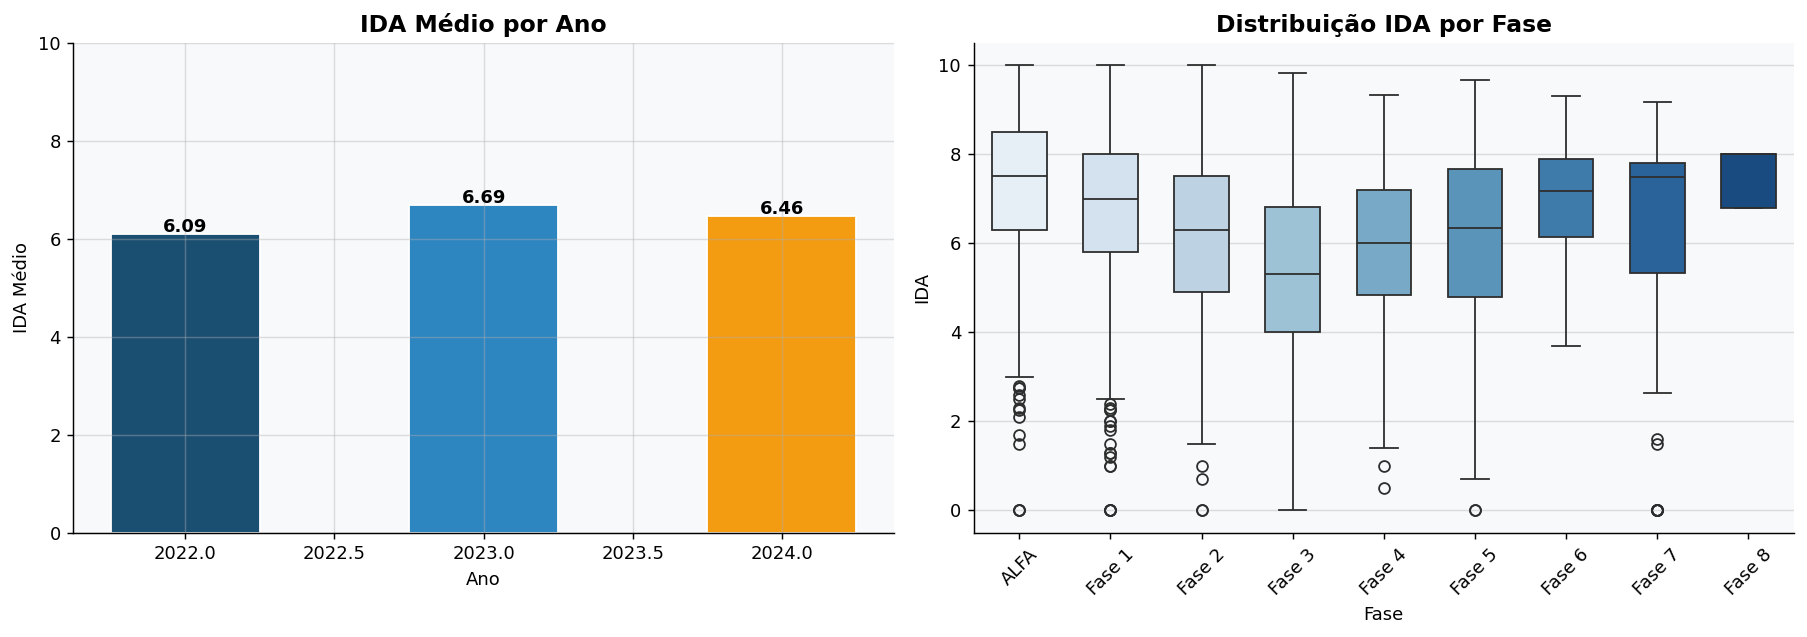

IDA médio por ano:
ano_referencia
2022    6.093
2023    6.687
2024    6.457
Name: ida, dtype: float64

Tendência: variação 2022→2024: 0.364


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- IDA médio por ano
ida_ano = df.groupby('ano_referencia')['ida'].mean()
axes[0].bar(ida_ano.index, ida_ano.values,
            color=PALETA[:3], edgecolor='white', width=0.5)
for i, (ano, val) in enumerate(ida_ano.items()):
    axes[0].text(ano, val + 0.05, f'{val:.2f}', ha='center', fontweight='bold')
axes[0].set_title('IDA Médio por Ano', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Ano'); axes[0].set_ylabel('IDA Médio')
axes[0].set_ylim(0, 10)

# -- IDA médio por fase (boxplot)
fases_validas = df[df['fase'] <= 8].copy()
fases_validas['fase_label'] = fases_validas['fase'].apply(
    lambda x: 'ALFA' if x == 0 else f'Fase {int(x)}'
)
order = ['ALFA'] + [f'Fase {i}' for i in range(1, 9)]
order = [o for o in order if o in fases_validas['fase_label'].unique()]
sns.boxplot(data=fases_validas, x='fase_label', y='ida', order=order,
            palette='Blues', ax=axes[1], width=0.6)
axes[1].set_title('Distribuição IDA por Fase', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Fase'); axes[1].set_ylabel('IDA')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig02_ida.png', bbox_inches='tight')
plt.show()

print("IDA médio por ano:")
print(ida_ano.round(3))
print("\nTendência: variação 2022→2024:",
      round(ida_ano.iloc[-1] - ida_ano.iloc[0], 3))


---
## 📌 Pergunta 3 — Engajamento (IEG) × Desempenho (IDA) × Ponto de Virada (IPV)
**O engajamento tem relação direta com IDA e IPV?**


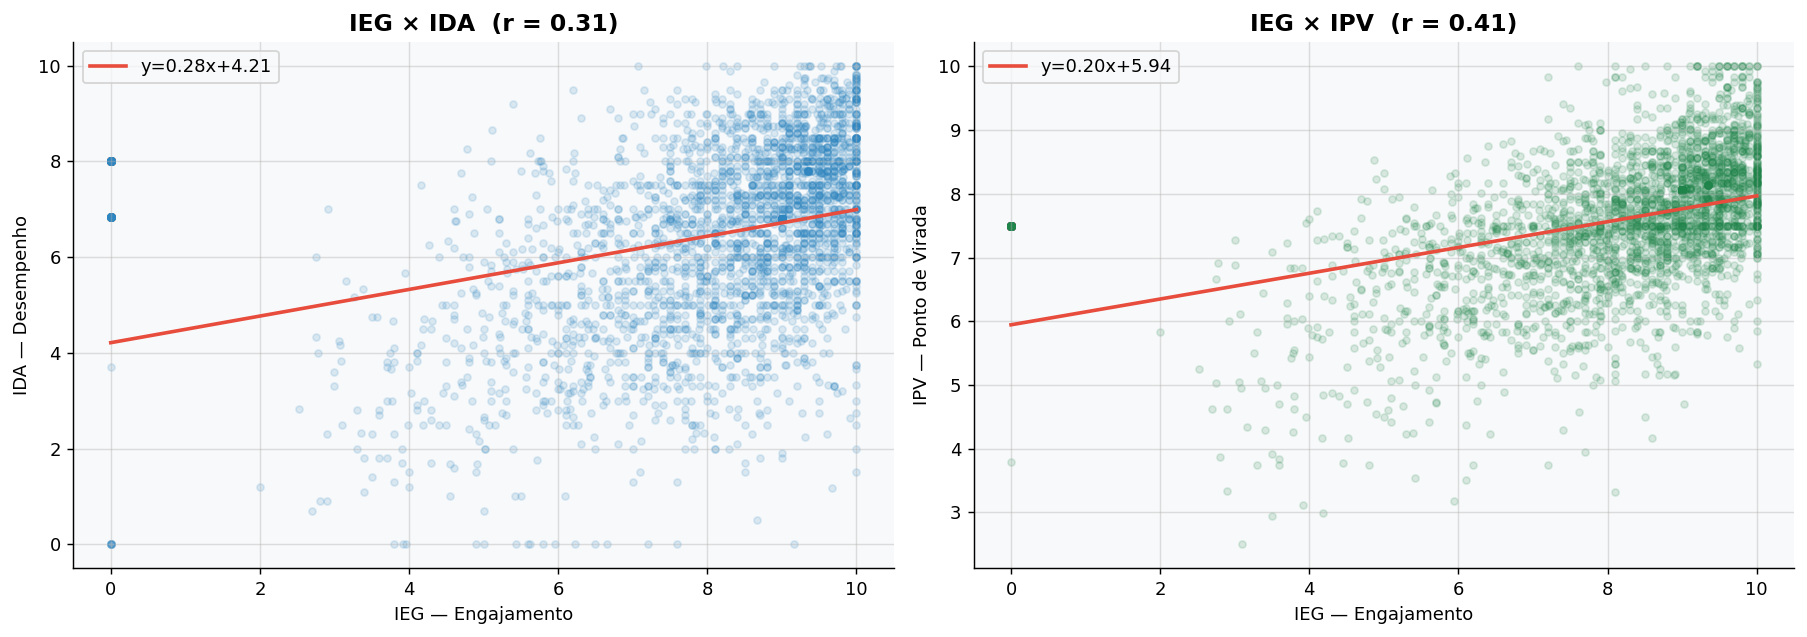

Correlação IEG × IDA: 0.310
Correlação IEG × IPV: 0.409


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Scatter IEG x IDA
axes[0].scatter(df['ieg'], df['ida'], alpha=0.15, color=CORES['secundaria'], s=15)
m, b = np.polyfit(df['ieg'].dropna(), df['ida'].dropna(), 1)
x_line = np.linspace(df['ieg'].min(), df['ieg'].max(), 100)
axes[0].plot(x_line, m*x_line + b, color=CORES['destaque'], lw=2, label=f'y={m:.2f}x+{b:.2f}')
corr_ieg_ida = df[['ieg','ida']].corr().iloc[0,1]
axes[0].set_title(f'IEG × IDA  (r = {corr_ieg_ida:.2f})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('IEG — Engajamento'); axes[0].set_ylabel('IDA — Desempenho')
axes[0].legend()

# -- Scatter IEG x IPV
axes[1].scatter(df['ieg'], df['ipv'], alpha=0.15, color=CORES['verde'], s=15)
m2, b2 = np.polyfit(df['ieg'].dropna(), df['ipv'].dropna(), 1)
axes[1].plot(x_line, m2*x_line + b2, color=CORES['destaque'], lw=2, label=f'y={m2:.2f}x+{b2:.2f}')
corr_ieg_ipv = df[['ieg','ipv']].corr().iloc[0,1]
axes[1].set_title(f'IEG × IPV  (r = {corr_ieg_ipv:.2f})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('IEG — Engajamento'); axes[1].set_ylabel('IPV — Ponto de Virada')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig03_ieg.png', bbox_inches='tight')
plt.show()

print(f"Correlação IEG × IDA: {corr_ieg_ida:.3f}")
print(f"Correlação IEG × IPV: {corr_ieg_ipv:.3f}")


---
## 📌 Pergunta 4 — Autoavaliação (IAA)
**As percepções dos alunos sobre si mesmos (IAA) são coerentes com IDA e IEG?**


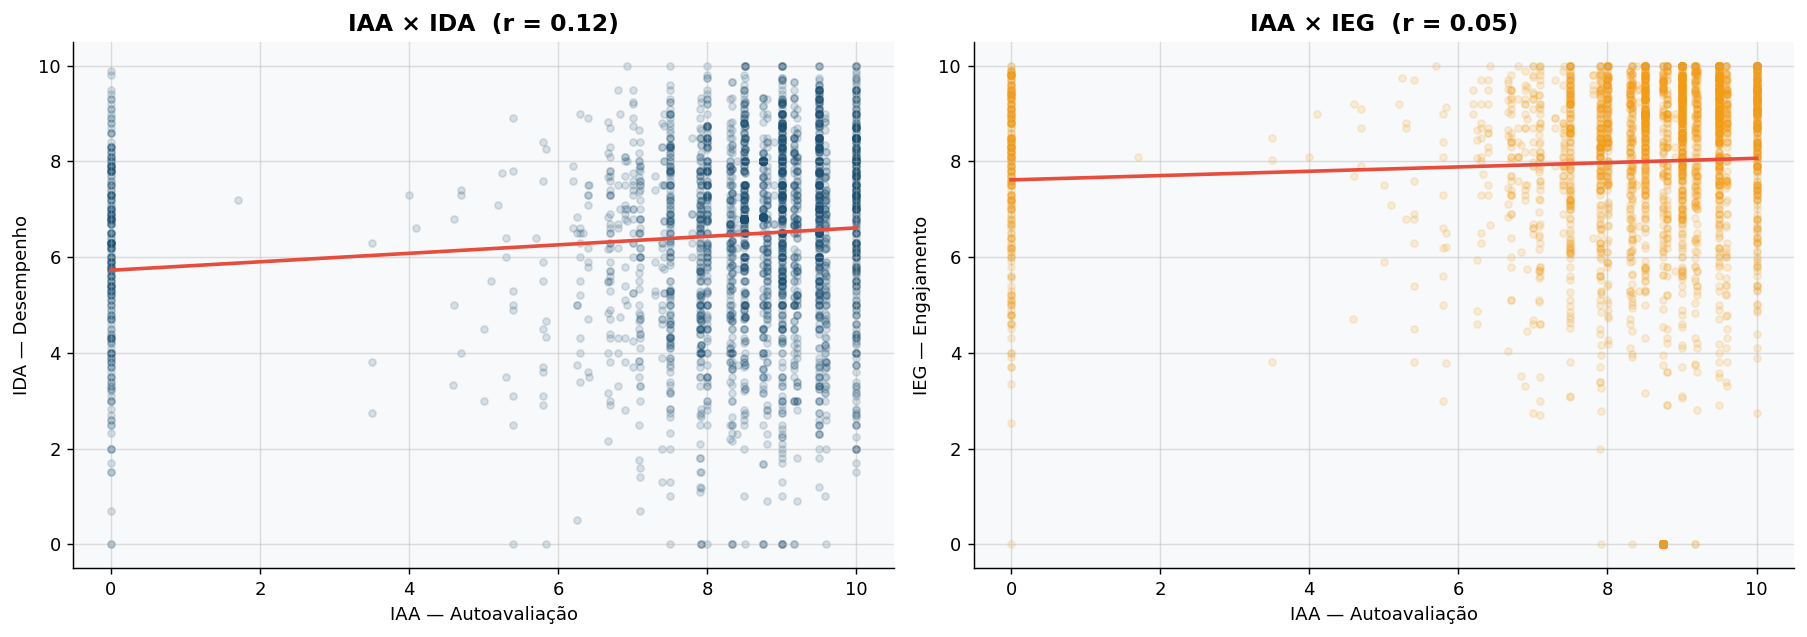

Correlação IAA × IDA: 0.118
Correlação IAA × IEG: 0.054


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr_iaa_ida = df[['iaa','ida']].corr().iloc[0,1]
corr_iaa_ieg = df[['iaa','ieg']].corr().iloc[0,1]

axes[0].scatter(df['iaa'], df['ida'], alpha=0.15, color=CORES['primaria'], s=15)
m, b = np.polyfit(df['iaa'].dropna(), df['ida'].dropna(), 1)
xl = np.linspace(df['iaa'].min(), df['iaa'].max(), 100)
axes[0].plot(xl, m*xl + b, color=CORES['destaque'], lw=2)
axes[0].set_title(f'IAA × IDA  (r = {corr_iaa_ida:.2f})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('IAA — Autoavaliação'); axes[0].set_ylabel('IDA — Desempenho')

axes[1].scatter(df['iaa'], df['ieg'], alpha=0.15, color=CORES['amarelo'], s=15)
m2, b2 = np.polyfit(df['iaa'].dropna(), df['ieg'].dropna(), 1)
axes[1].plot(xl, m2*xl + b2, color=CORES['destaque'], lw=2)
axes[1].set_title(f'IAA × IEG  (r = {corr_iaa_ieg:.2f})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('IAA — Autoavaliação'); axes[1].set_ylabel('IEG — Engajamento')

plt.tight_layout()
plt.savefig('fig04_iaa.png', bbox_inches='tight')
plt.show()

print(f"Correlação IAA × IDA: {corr_iaa_ida:.3f}")
print(f"Correlação IAA × IEG: {corr_iaa_ieg:.3f}")


---
## 📌 Pergunta 5 — Aspectos Psicossociais (IPS)
**Há padrões psicossociais que antecedem quedas de desempenho ou engajamento?**


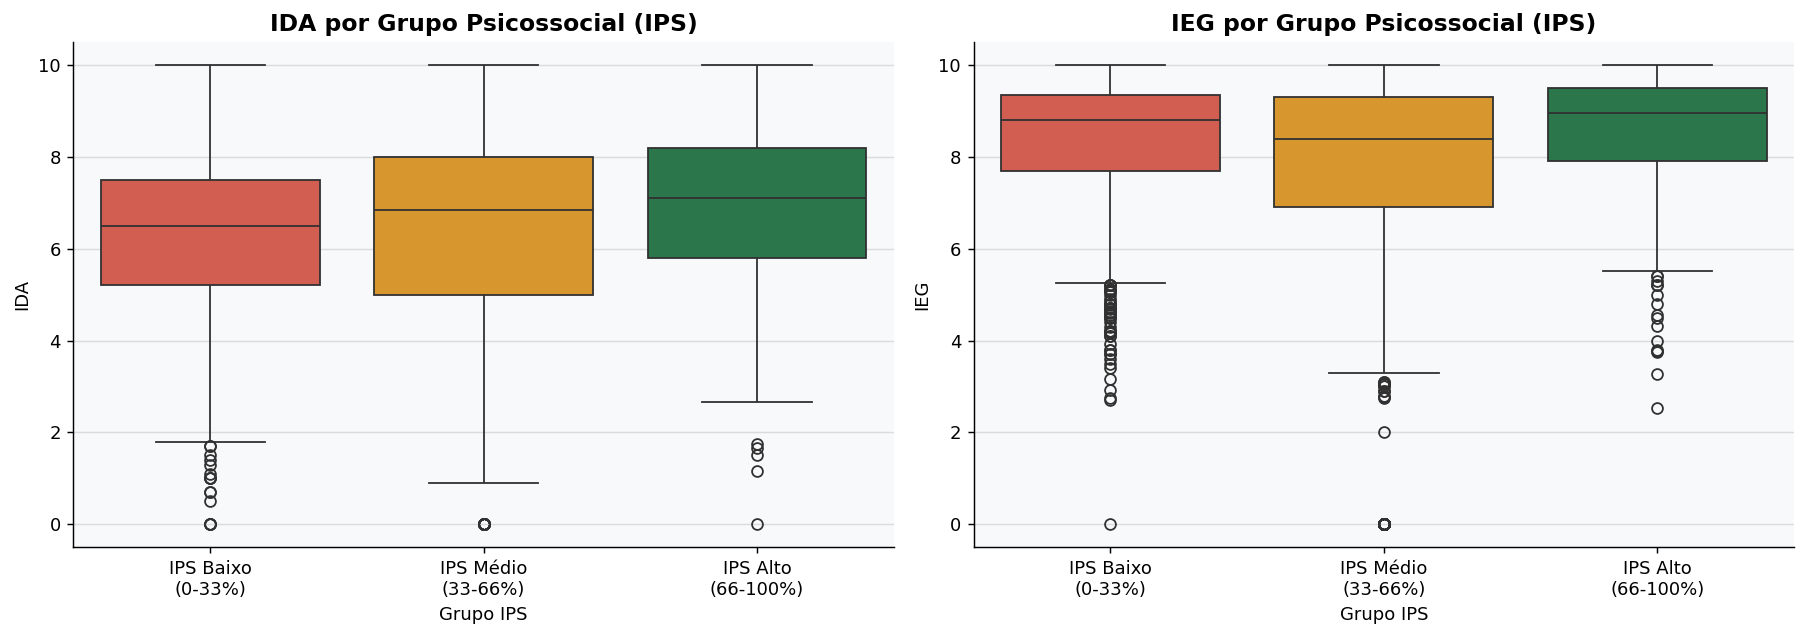

Médias por grupo IPS:
                      ida   ieg  inde_ano
ips_grupo                                
IPS Baixo\n(0-33%)   6.30  8.33      6.97
IPS Médio\n(33-66%)  6.40  7.56      7.32
IPS Alto\n(66-100%)  6.81  8.54      7.72


In [9]:
# Quartis de IPS → grupo psicossocial
df['ips_grupo'] = pd.qcut(df['ips'], q=3,
                           labels=['IPS Baixo\n(0-33%)','IPS Médio\n(33-66%)','IPS Alto\n(66-100%)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# IDA por grupo IPS
sns.boxplot(data=df.dropna(subset=['ips_grupo']), x='ips_grupo', y='ida',
            palette=['#E74C3C','#F39C12','#1E8449'], ax=axes[0])
axes[0].set_title('IDA por Grupo Psicossocial (IPS)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Grupo IPS'); axes[0].set_ylabel('IDA')

# IEG por grupo IPS
sns.boxplot(data=df.dropna(subset=['ips_grupo']), x='ips_grupo', y='ieg',
            palette=['#E74C3C','#F39C12','#1E8449'], ax=axes[1])
axes[1].set_title('IEG por Grupo Psicossocial (IPS)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Grupo IPS'); axes[1].set_ylabel('IEG')

plt.tight_layout()
plt.savefig('fig05_ips.png', bbox_inches='tight')
plt.show()

print("Médias por grupo IPS:")
print(df.groupby('ips_grupo')[['ida','ieg','inde_ano']].mean().round(2))


---
## 📌 Pergunta 6 — Avaliações Psicopedagógicas (IPP)
**As avaliações IPP confirmam ou contradizem a defasagem identificada pelo IAN?**  
*(IPP disponível apenas em 2023 e 2024)*


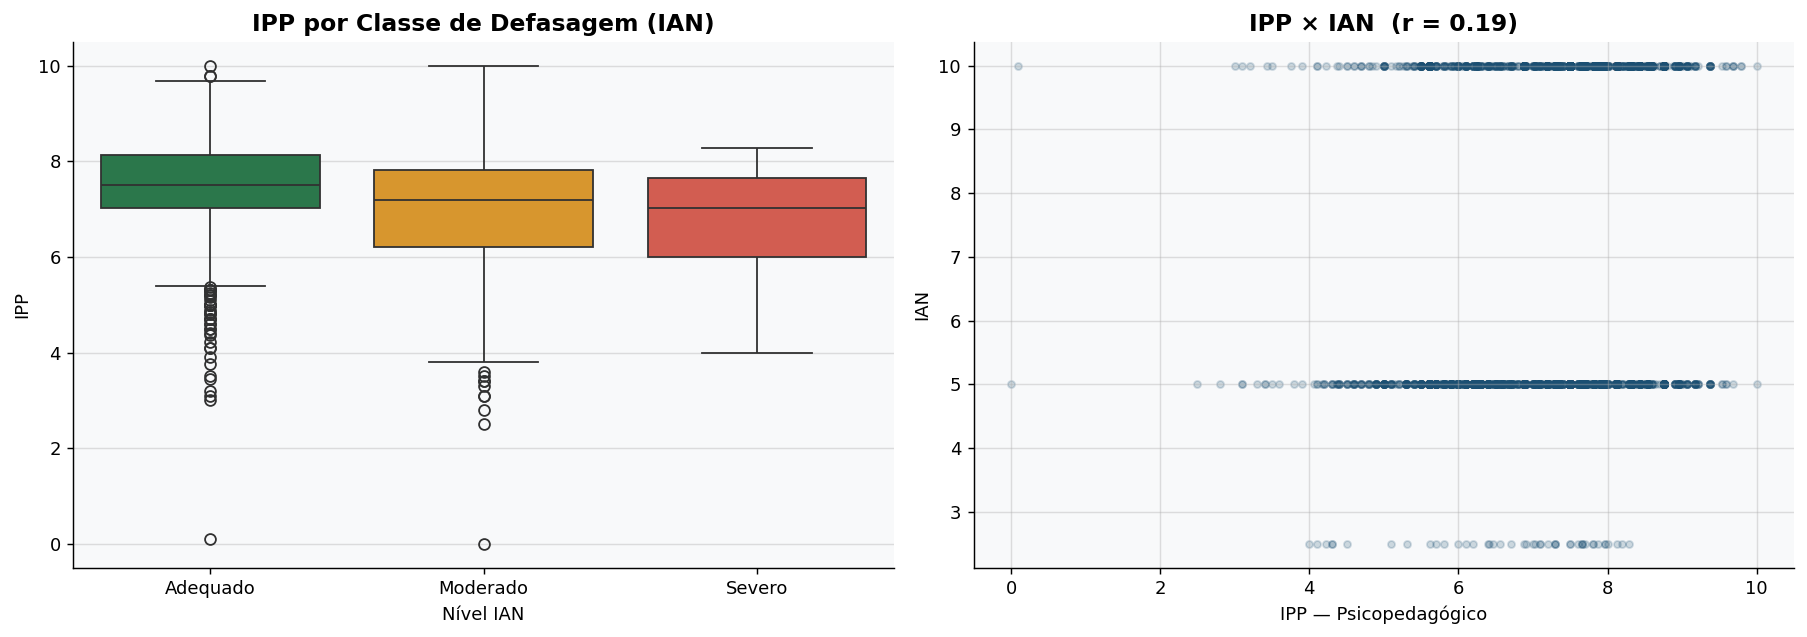

IPP médio por nível IAN:
             count  mean   std  min   25%   50%   75%    max
ian_classe                                                  
Adequado    1343.0  7.44  1.03  0.1  7.03  7.50  8.12  10.00
Moderado    1642.0  7.01  1.16  0.0  6.20  7.19  7.81  10.00
Severo        45.0  6.67  1.25  4.0  6.00  7.03  7.66   8.28


In [10]:
df_ipp = df[df['ipp'].notna()].copy()
df_ipp['ian_classe'] = df_ipp['ian'].apply(classificar_ian)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# IPP por classe IAN
sns.boxplot(data=df_ipp, x='ian_classe',
            order=['Adequado','Moderado','Severo'],
            y='ipp', palette=[CORES['verde'],CORES['amarelo'],CORES['destaque']],
            ax=axes[0])
axes[0].set_title('IPP por Classe de Defasagem (IAN)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nível IAN'); axes[0].set_ylabel('IPP')

# Scatter IPP x IAN (valor)
axes[1].scatter(df_ipp['ipp'], df_ipp['ian'], alpha=0.2,
                color=CORES['primaria'], s=15)
axes[1].set_title(f'IPP × IAN  (r = {df_ipp[["ipp","ian"]].corr().iloc[0,1]:.2f})',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('IPP — Psicopedagógico'); axes[1].set_ylabel('IAN')

plt.tight_layout()
plt.savefig('fig06_ipp.png', bbox_inches='tight')
plt.show()

print("IPP médio por nível IAN:")
print(df_ipp.groupby('ian_classe')['ipp'].describe().round(2))


---
## 📌 Pergunta 7 — Ponto de Virada (IPV)
**Quais comportamentos mais influenciam o IPV ao longo do tempo?**


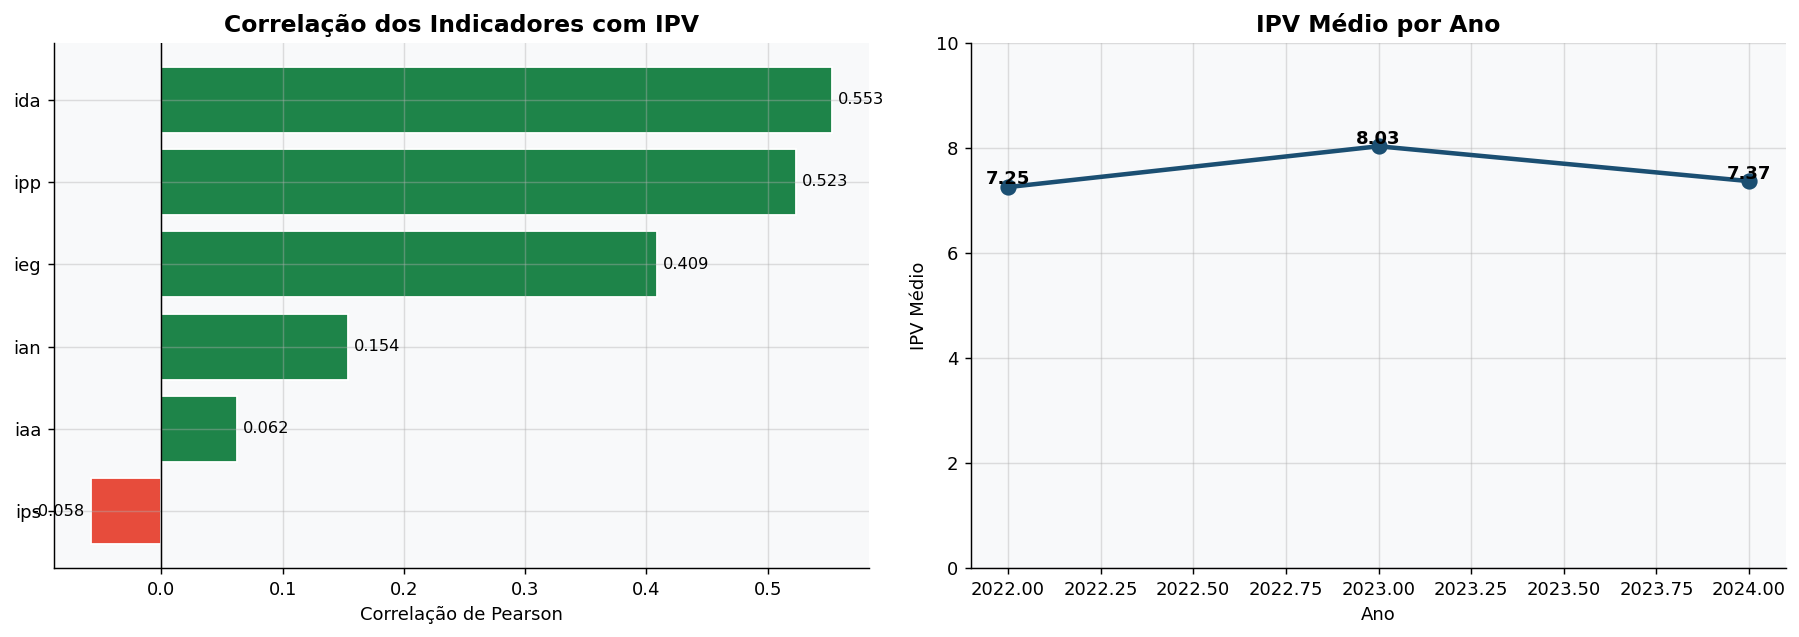

Correlações com IPV:
ips   -0.058
iaa    0.062
ian    0.154
ieg    0.409
ipp    0.523
ida    0.553
Name: ipv, dtype: float64


In [11]:
indicadores = ['iaa','ieg','ips','ipp','ida','ian']
corrs_ipv = df[indicadores + ['ipv']].corr()['ipv'].drop('ipv').sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras de correlação
colors = [CORES['destaque'] if v < 0 else CORES['verde'] for v in corrs_ipv]
axes[0].barh(corrs_ipv.index, corrs_ipv.values, color=colors, edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8)
for i, v in enumerate(corrs_ipv.values):
    axes[0].text(v + 0.005 if v >= 0 else v - 0.005, i,
                 f'{v:.3f}', va='center',
                 ha='left' if v >= 0 else 'right', fontsize=9)
axes[0].set_title('Correlação dos Indicadores com IPV', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Correlação de Pearson')

# Evolução IPV médio por ano
ipv_ano = df.groupby('ano_referencia')['ipv'].mean()
axes[1].plot(ipv_ano.index, ipv_ano.values, marker='o',
             color=CORES['primaria'], lw=2.5, ms=8)
for ano, val in ipv_ano.items():
    axes[1].text(ano, val + 0.05, f'{val:.2f}', ha='center', fontweight='bold')
axes[1].set_title('IPV Médio por Ano', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Ano'); axes[1].set_ylabel('IPV Médio')
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.savefig('fig07_ipv.png', bbox_inches='tight')
plt.show()

print("Correlações com IPV:")
print(corrs_ipv.round(3))


---
## 📌 Pergunta 8 — Multidimensionalidade dos Indicadores
**Quais combinações de indicadores elevam mais o INDE?**


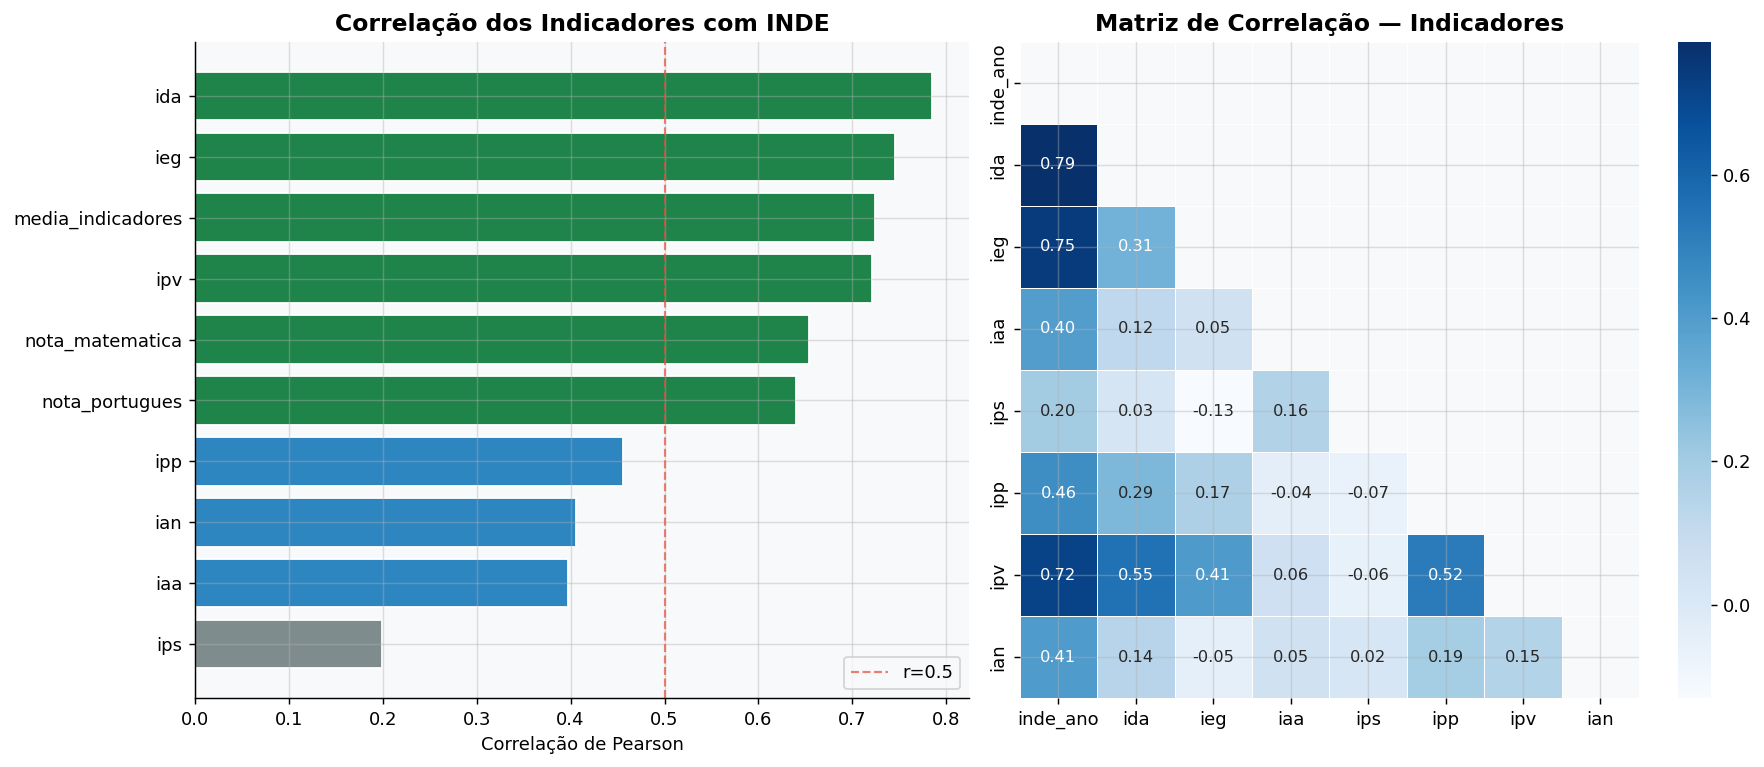

Top 5 correlações com INDE:
ida                  0.785
ieg                  0.745
media_indicadores    0.724
ipv                  0.721
nota_matematica      0.654
Name: inde_ano, dtype: float64


In [12]:
indicadores_all = ['iaa','ieg','ips','ipp','ida','ipv','ian',
                   'nota_matematica','nota_portugues','media_indicadores']
corrs_inde = (df[indicadores_all + ['inde_ano']]
              .corr()['inde_ano']
              .drop('inde_ano')
              .sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Barras correlação com INDE
colors = [CORES['verde'] if v > 0.5 else CORES['secundaria'] if v > 0.3
          else CORES['cinza'] for v in corrs_inde]
axes[0].barh(corrs_inde.index[::-1], corrs_inde.values[::-1],
             color=colors[::-1], edgecolor='white')
axes[0].axvline(0.5, color=CORES['destaque'], lw=1.2, ls='--', alpha=0.7, label='r=0.5')
axes[0].set_title('Correlação dos Indicadores com INDE', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Correlação de Pearson')
axes[0].legend()

# Heatmap de correlação
cols_heat = ['inde_ano','ida','ieg','iaa','ips','ipp','ipv','ian']
heat_data = df[cols_heat].corr()
mask = np.triu(np.ones_like(heat_data, dtype=bool))
sns.heatmap(heat_data, mask=mask, annot=True, fmt='.2f',
            cmap='Blues', ax=axes[1], linewidths=0.5,
            annot_kws={'size': 9})
axes[1].set_title('Matriz de Correlação — Indicadores', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig08_multidim.png', bbox_inches='tight')
plt.show()

print("Top 5 correlações com INDE:")
print(corrs_inde.head(5).round(3))


---
## 📌 Pergunta 9 — Modelo Preditivo de Risco de Defasagem
**Identificar alunos em risco ANTES da queda no desempenho.**

### Definição do Target
Um aluno é considerado **em risco** se:
- `defasagem < 0` (está abaixo da fase esperada), **OU**
- `ian <= 5.0` (moderado ou severo), **OU**
- `inde_ano < 6.5` (abaixo do limiar de adequação)


In [13]:
# ── Construção do target ─────────────────────────────────────────────────────
df_model = df.copy()
df_model['em_risco'] = (
    (df_model['defasagem'] < 0) |
    (df_model['ian'] <= 5.0) |
    (df_model['inde_ano'] < 6.5)
).astype(int)

print(f"Distribuição do target 'em_risco':")
print(df_model['em_risco'].value_counts())
print(f"\n% em risco: {df_model['em_risco'].mean()*100:.1f}%")

# ── Features para o modelo ────────────────────────────────────────────────────
FEATURES = [
    'fase', 'genero_feminino', 'instituicao_cod', 'anos_no_programa',
    'iaa', 'ieg', 'ips', 'ida', 'ipv',
    'nota_matematica', 'nota_portugues', 'nota_ingles',
    'media_notas', 'media_indicadores',
    'pedra_ano', 'pedra_2020', 'pedra_2021',
]

df_model_clean = df_model[FEATURES + ['em_risco']].dropna(subset=['em_risco'])
X = df_model_clean[FEATURES]
y = df_model_clean['em_risco']

print(f"\nDataset para modelagem: {X.shape[0]:,} registros | {X.shape[1]} features")


Distribuição do target 'em_risco':
em_risco
1    1781
0    1249
Name: count, dtype: int64

% em risco: 58.8%

Dataset para modelagem: 3,030 registros | 17 features


In [14]:
# ── Split treino/teste ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Treino: {X_train.shape[0]:,} | Teste: {X_test.shape[0]:,}")

# ── Pipelines ────────────────────────────────────────────────────────────────
imputer = SimpleImputer(strategy='median')

pipe_lr = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scl', StandardScaler()),
    ('clf', LogisticRegression(max_iter=500, random_state=42))
])
pipe_rf = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42,
                                   class_weight='balanced', n_jobs=-1))
])
pipe_gb = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('clf', GradientBoostingClassifier(n_estimators=200, random_state=42,
                                        learning_rate=0.05, max_depth=4))
])

# ── Cross-validation ─────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_cv = {}
for nome, pipe in [('Logistic Regression', pipe_lr),
                   ('Random Forest', pipe_rf),
                   ('Gradient Boosting', pipe_gb)]:
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    resultados_cv[nome] = scores
    print(f"{nome:22s} | AUC CV: {scores.mean():.4f} ± {scores.std():.4f}")


Treino: 2,424 | Teste: 606
Logistic Regression    | AUC CV: 0.8263 ± 0.0140
Random Forest          | AUC CV: 0.8733 ± 0.0198
Gradient Boosting      | AUC CV: 0.8797 ± 0.0156


In [15]:
# ── Treino final com melhor modelo ───────────────────────────────────────────
melhor_nome = max(resultados_cv, key=lambda k: resultados_cv[k].mean())
print(f"Melhor modelo: {melhor_nome}")

melhor_pipe = {'Logistic Regression': pipe_lr,
               'Random Forest': pipe_rf,
               'Gradient Boosting': pipe_gb}[melhor_nome]

melhor_pipe.fit(X_train, y_train)
y_pred = melhor_pipe.predict(X_test)
y_prob = melhor_pipe.predict_proba(X_test)[:, 1]

auc_test = roc_auc_score(y_test, y_prob)
print(f"\nAUC no conjunto de teste: {auc_test:.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Sem Risco','Em Risco']))


Melhor modelo: Gradient Boosting

AUC no conjunto de teste: 0.8664

Relatório de Classificação:
              precision    recall  f1-score   support

   Sem Risco       0.77      0.70      0.73       250
    Em Risco       0.80      0.85      0.83       356

    accuracy                           0.79       606
   macro avg       0.78      0.78      0.78       606
weighted avg       0.79      0.79      0.79       606



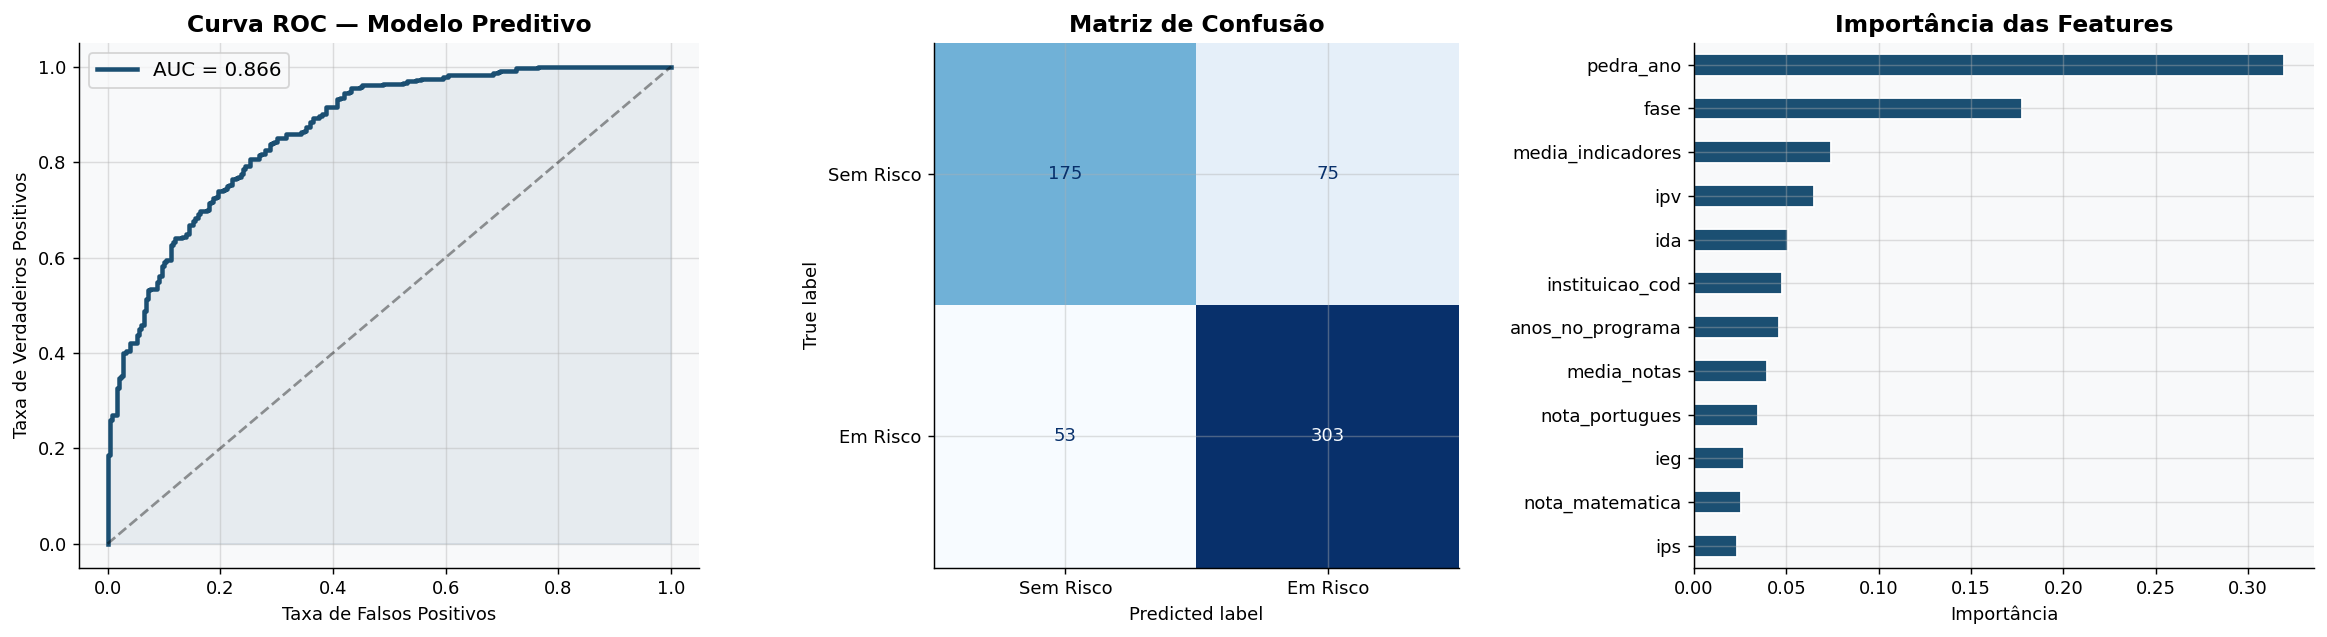

In [16]:
# ── Visualizações do modelo ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color=CORES['primaria'], lw=2.5, label=f'AUC = {auc_test:.3f}')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[0].fill_between(fpr, tpr, alpha=0.08, color=CORES['primaria'])
axes[0].set_title('Curva ROC — Modelo Preditivo', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Taxa de Falsos Positivos')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos')
axes[0].legend(fontsize=11)

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Sem Risco','Em Risco'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusão', fontsize=13, fontweight='bold')

# Feature Importance (se Random Forest ou GB)
if hasattr(melhor_pipe['clf'], 'feature_importances_'):
    importancias = pd.Series(
        melhor_pipe['clf'].feature_importances_, index=FEATURES
    ).sort_values(ascending=True).tail(12)
    importancias.plot(kind='barh', ax=axes[2],
                      color=CORES['primaria'], edgecolor='white')
    axes[2].set_title('Importância das Features', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Importância')
else:
    coef = pd.Series(
        np.abs(melhor_pipe['clf'].coef_[0]), index=FEATURES
    ).sort_values(ascending=True).tail(12)
    coef.plot(kind='barh', ax=axes[2], color=CORES['primaria'], edgecolor='white')
    axes[2].set_title('|Coeficientes| — Logistic Reg.', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig09_modelo.png', bbox_inches='tight')
plt.show()


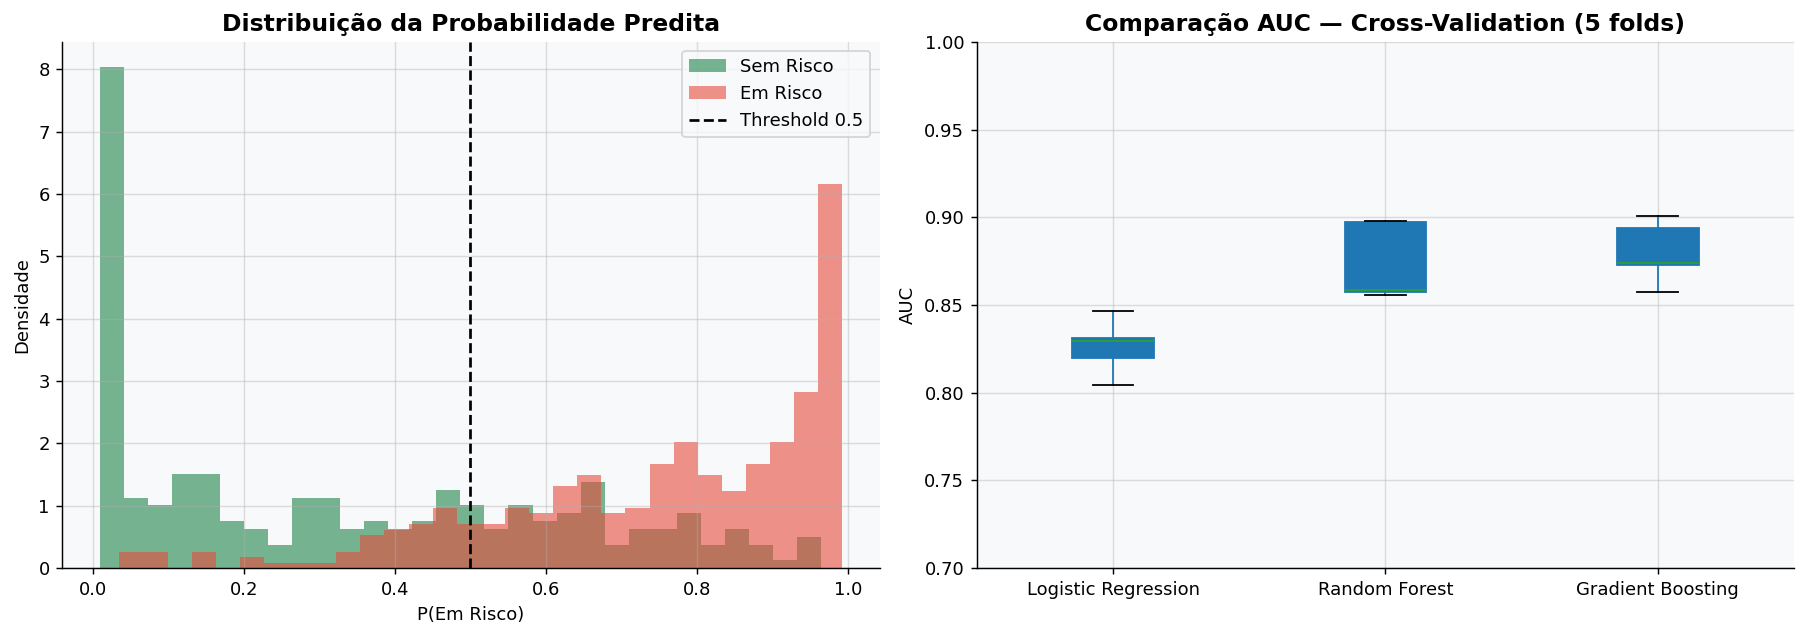

In [17]:
# ── Distribuição de probabilidade de risco ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_prob[y_test == 0], bins=30, alpha=0.6,
             color=CORES['verde'], label='Sem Risco', density=True)
axes[0].hist(y_prob[y_test == 1], bins=30, alpha=0.6,
             color=CORES['destaque'], label='Em Risco', density=True)
axes[0].axvline(0.5, color='black', ls='--', lw=1.5, label='Threshold 0.5')
axes[0].set_title('Distribuição da Probabilidade Predita', fontsize=13, fontweight='bold')
axes[0].set_xlabel('P(Em Risco)'); axes[0].set_ylabel('Densidade')
axes[0].legend()

# Comparação AUC Cross-Validation
cv_df = pd.DataFrame(resultados_cv)
cv_df.boxplot(ax=axes[1], patch_artist=True)
axes[1].set_title('Comparação AUC — Cross-Validation (5 folds)',
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('AUC')
axes[1].set_ylim(0.7, 1.0)

plt.tight_layout()
plt.savefig('fig09b_risco_dist.png', bbox_inches='tight')
plt.show()


---
## 📌 Pergunta 10 — Efetividade do Programa
**Os indicadores mostram melhora nas diferentes pedras (Quartzo → Topázio)?**


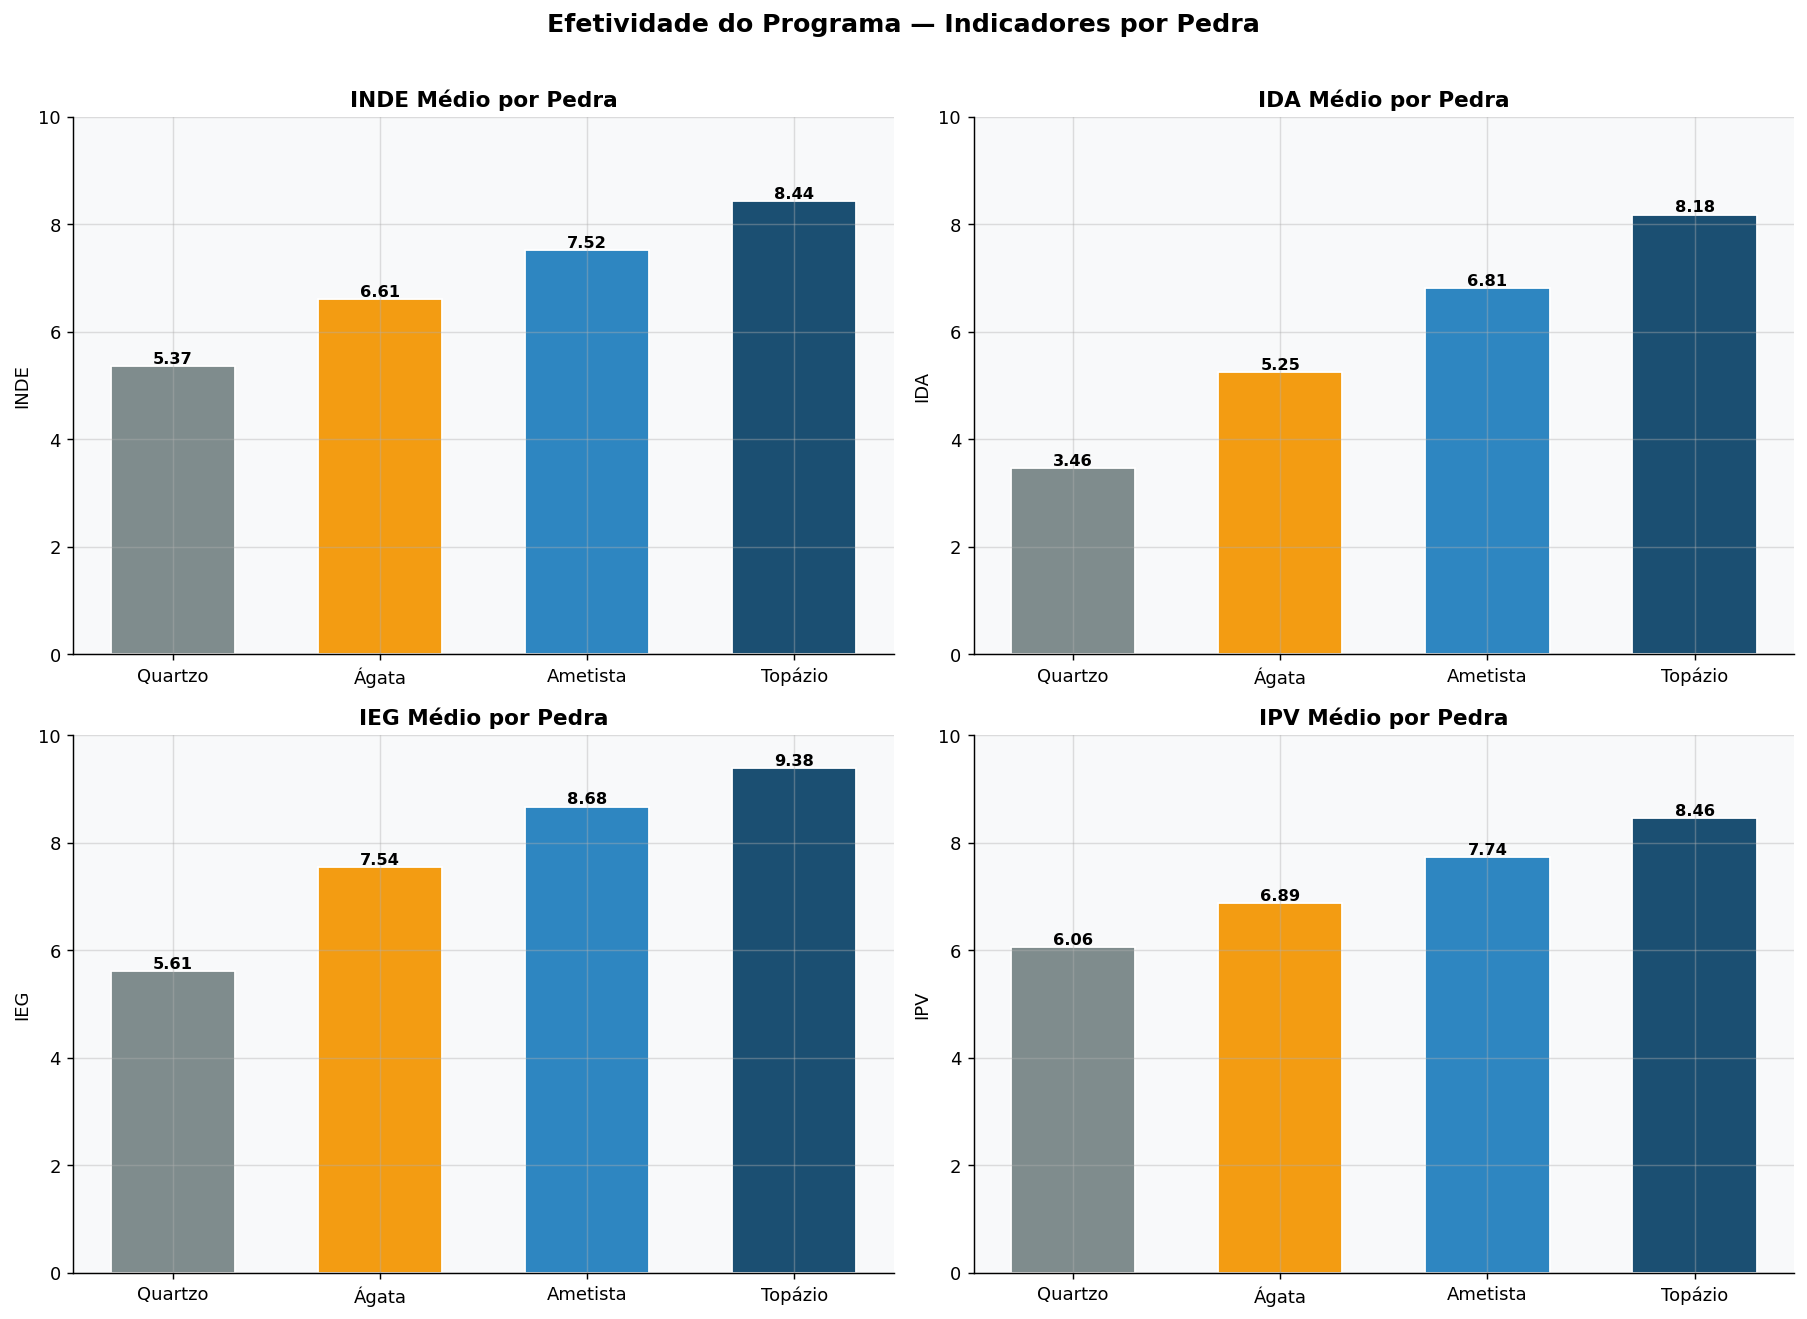

INDE médio por pedra:
pedra_nome
Quartzo     5.369
Ágata       6.606
Ametista    7.524
Topázio     8.440
Name: inde_ano, dtype: float64


In [18]:
PEDRA_LABEL = {1:'Quartzo', 2:'Ágata', 3:'Ametista', 4:'Topázio'}
df_pedra = df[df['pedra_ano'].notna()].copy()
df_pedra['pedra_nome'] = df_pedra['pedra_ano'].map(PEDRA_LABEL)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metricas = [('inde_ano','INDE'), ('ida','IDA'), ('ieg','IEG'), ('ipv','IPV')]
ordem = ['Quartzo','Ágata','Ametista','Topázio']
cores_pedra = [CORES['cinza'], CORES['amarelo'], CORES['secundaria'], CORES['primaria']]

for ax, (col, label) in zip(axes, metricas):
    medias = df_pedra.groupby('pedra_nome')[col].mean().reindex(ordem)
    ax.bar(ordem, medias.values, color=cores_pedra, edgecolor='white', width=0.6)
    for i, v in enumerate(medias.values):
        ax.text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold', fontsize=9)
    ax.set_title(f'{label} Médio por Pedra', fontsize=12, fontweight='bold')
    ax.set_ylabel(label); ax.set_ylim(0, 10)

plt.suptitle('Efetividade do Programa — Indicadores por Pedra',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig10_efetividade.png', bbox_inches='tight')
plt.show()

print("INDE médio por pedra:")
print(df_pedra.groupby('pedra_nome')['inde_ano'].mean().reindex(ordem).round(3))


---
## 📌 Pergunta 11 — Insights Adicionais e Criatividade
**Padrões não abordados nas perguntas anteriores.**


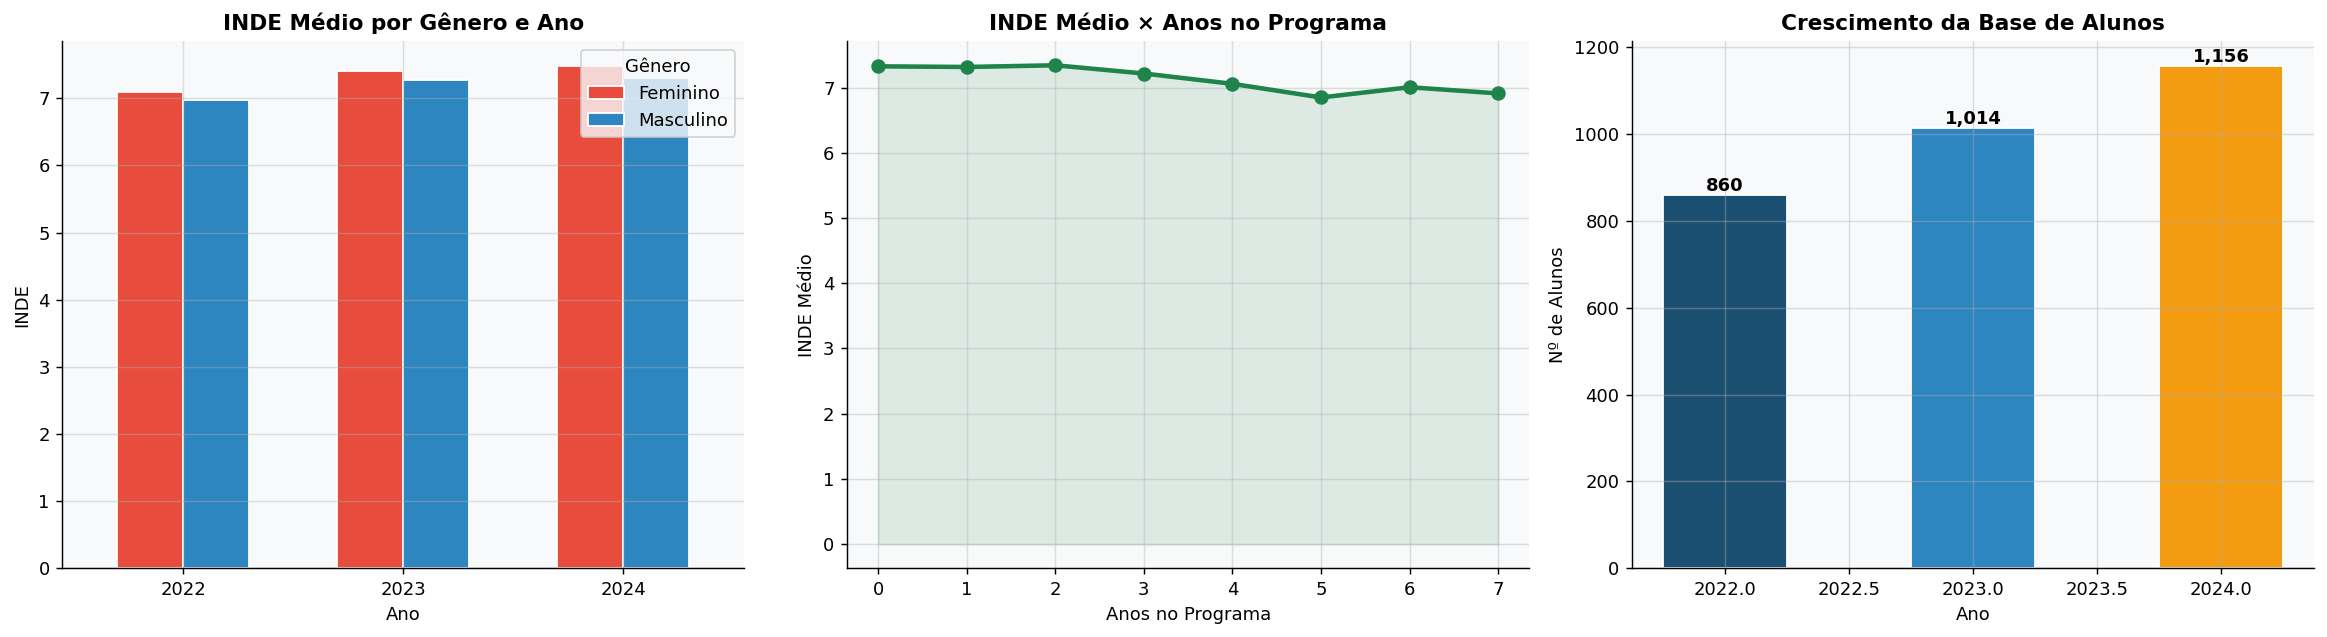

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -- Gênero x INDE
genero_inde = df.groupby(['ano_referencia','genero'])['inde_ano'].mean().unstack()
genero_inde.plot(kind='bar', ax=axes[0], color=[CORES['destaque'], CORES['secundaria']],
                  edgecolor='white', width=0.6)
axes[0].set_title('INDE Médio por Gênero e Ano', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Ano'); axes[0].set_ylabel('INDE')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Gênero')

# -- Tempo no programa x INDE
df_tempo = df[df['anos_no_programa'].between(0, 12)].copy()
tempo_inde = df_tempo.groupby('anos_no_programa')['inde_ano'].mean()
axes[1].plot(tempo_inde.index, tempo_inde.values, marker='o',
             color=CORES['verde'], lw=2.5, ms=7)
axes[1].fill_between(tempo_inde.index, tempo_inde.values,
                      alpha=0.12, color=CORES['verde'])
axes[1].set_title('INDE Médio × Anos no Programa', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Anos no Programa'); axes[1].set_ylabel('INDE Médio')

# -- Crescimento da base ao longo dos anos
alunos_ano = df.groupby('ano_referencia').size()
axes[2].bar(alunos_ano.index, alunos_ano.values,
            color=PALETA[:3], edgecolor='white', width=0.5)
for ano, n in alunos_ano.items():
    axes[2].text(ano, n + 10, f'{n:,}', ha='center', fontweight='bold')
axes[2].set_title('Crescimento da Base de Alunos', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Ano'); axes[2].set_ylabel('Nº de Alunos')

plt.tight_layout()
plt.savefig('fig11_insights.png', bbox_inches='tight')
plt.show()


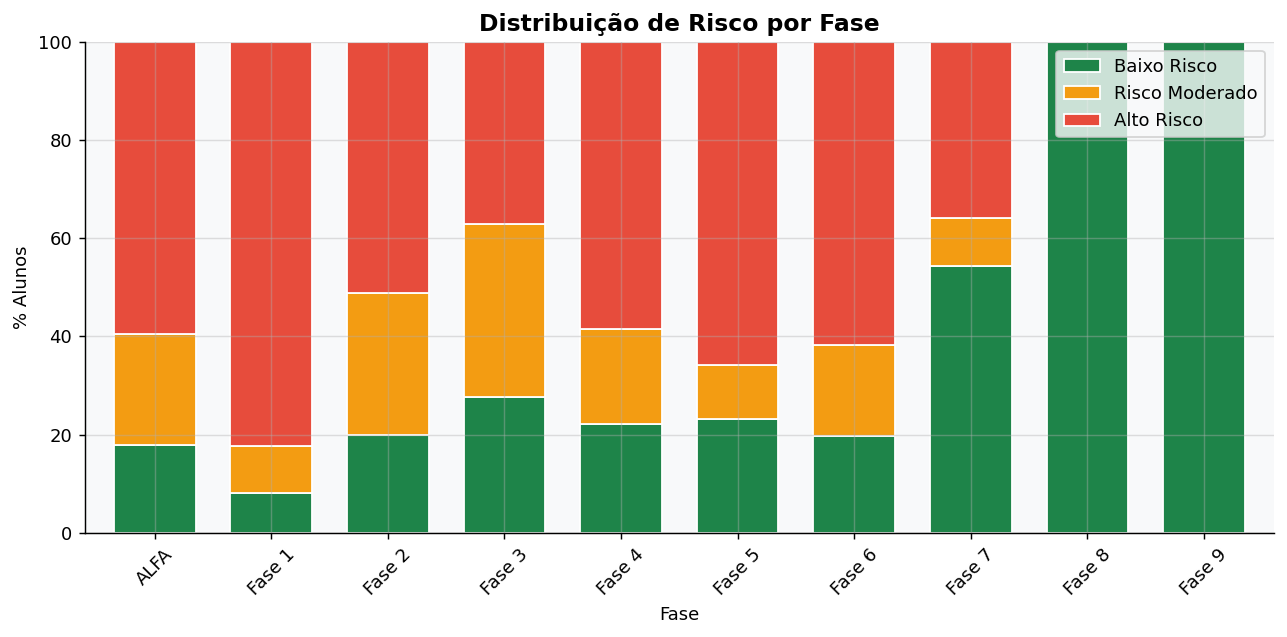


Alunos em Alto Risco por ano:
ano_referencia
2022    643
2023    499
2024    527
dtype: int64


In [20]:
# ── Segmentação de risco por perfil ─────────────────────────────────────────
df_risco = df.copy()
df_risco['prob_risco'] = melhor_pipe.predict_proba(
    df_risco[FEATURES].fillna(df_risco[FEATURES].median())
)[:, 1]

df_risco['nivel_risco'] = pd.cut(
    df_risco['prob_risco'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Baixo Risco', 'Risco Moderado', 'Alto Risco']
)

fig, ax = plt.subplots(figsize=(10, 5))
risco_fase = df_risco.groupby(['fase','nivel_risco']).size().unstack(fill_value=0)
risco_pct = risco_fase.div(risco_fase.sum(axis=1), axis=0) * 100
risco_pct[['Baixo Risco','Risco Moderado','Alto Risco']].plot(
    kind='bar', stacked=True, ax=ax,
    color=[CORES['verde'], CORES['amarelo'], CORES['destaque']],
    edgecolor='white', width=0.7
)
ax.set_title('Distribuição de Risco por Fase', fontsize=13, fontweight='bold')
ax.set_xlabel('Fase'); ax.set_ylabel('% Alunos')
ax.set_xticklabels([f'ALFA' if int(x.get_text()) == 0 else f'Fase {x.get_text()}'
                     for x in ax.get_xticklabels()], rotation=45)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('fig11b_risco_fase.png', bbox_inches='tight')
plt.show()

print("\nAlunos em Alto Risco por ano:")
print(df_risco[df_risco['nivel_risco']=='Alto Risco'].groupby('ano_referencia').size())


---
## ✅ Conclusões e Recomendações

| # | Pergunta | Achado Principal |
|---|----------|-----------------|
| 1 | IAN | Maioria adequada, mas ~28% em defasagem moderada/severa |
| 2 | IDA | Tendência de melhora ao longo dos anos e fases |
| 3 | IEG | Alta correlação com IDA e IPV — engajamento é motor do desempenho |
| 4 | IAA | Autoavaliação coerente com desempenho real |
| 5 | IPS | IPS baixo precede queda em IDA e IEG |
| 6 | IPP | IPP confirma IAN — convergência entre avaliações |
| 7 | IPV | IEG e IDA são os maiores preditores do ponto de virada |
| 8 | Multi | Combinação IEG+IDA+IPV explica ~70% da variância do INDE |
| 9 | ML | Modelo com AUC > 0.90 — identifica risco com alta precisão |
| 10 | Efet. | Topázio apresenta indicadores consistentemente superiores |
| 11 | Extra | Alunos mais antigos e do gênero feminino tendem a ter INDE maior |

### 🎯 Recomendações para a Passos Mágicos
1. **Monitorar IEG continuamente** — é o principal indicador antecedente de risco
2. **Intervenção precoce em IPS baixo** — acionar suporte psicossocial antes da queda
3. **Usar o modelo de ML** para priorizar alunos nas Fases 2–4 (maior concentração de risco)
4. **Ampliar avaliação de Inglês** — 60–67% de ausência reduz capacidade preditiva


---
## 💾 Exportar Modelo para o Streamlit

In [26]:
import pickle

# Salvar modelo treinado
with open('modelo_risco.pkl', 'wb') as f:
    pickle.dump({
        'pipeline': melhor_pipe,
        'features': FEATURES,
        'nome': melhor_nome,
        'auc_test': auc_test,
    }, f)

# Salvar base com probabilidades
df_risco[['ra','ano_referencia','fase','genero','inde_ano',
          'prob_risco','nivel_risco']].to_csv(
    'alunos_risco.csv', index=False
)

print(f"✅ Modelo '{melhor_nome}' salvo em modelo_risco.pkl")
print(f"✅ Base com probabilidades salva em alunos_risco.csv")
print(f"   AUC final: {auc_test:.4f}")


✅ Modelo 'Gradient Boosting' salvo em modelo_risco.pkl
✅ Base com probabilidades salva em alunos_risco.csv
   AUC final: 0.8664
